## Example of TBR

Paper: https://storage.googleapis.com/pub-tools-public-publication-data/pdf/45950.pdf

Notes
* Assumes there is only one treated series that has been pre-aggregated.
* It can handle multiple controls, if you use TBRRidge 
* This method does extrapolate  

In [45]:
from __future__ import annotations 
import pandas as pd 
from panel_exp.panel_data import PanelDataset, TimePeriod, long_df_to_paneldataset
from panel_exp.methods.tbr import TBR, TBRRidge 

In [31]:
# Load Google Sales Dataset
long_df = pd.read_csv('google_sales.csv')

In [33]:
long_df.head()

,date,geo,sales,cost,group
0,2015-01-05,1,7227.32,0.0,2
1,2015-01-05,10,1827.21,0.0,1
2,2015-01-05,100,23.98,0.0,1
3,2015-01-05,11,1501.10,0.0,1
4,2015-01-05,12,1371.61,0.0,2


In [34]:
pre_test_start = '2015-01-05'
pre_test_end   = '2015-02-15'

test_start = '2015-02-16'
test_end   = '2015-03-15'

In [ ]:
treated_units = long_df[long_df.group==2].geo.unique()

In [52]:
len(treated_units)

50

In [54]:
len([ test_start for _ in range(len(treated_units))])

50

In [55]:
wide_df = pd.pivot_table(long_df, index='geo', columns='date', values='sales', aggfunc=sum, fill_value=0)

/var/folders/cd/dfrqgp4s4ll55cwb7rtgccbw0000gq/T/ipykernel_30817/1368796011.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  wide_df = pd.pivot_table(long_df, index='geo', columns='date', values='sales', aggfunc=sum, fill_value=0)


In [57]:
wide_df

date,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-10,2015-01-11,2015-01-12,2015-01-13,2015-01-14,...,2015-03-29,2015-03-30,2015-03-31,2015-04-01,2015-04-02,2015-04-03,2015-04-04,2015-04-05,2015-04-06,2015-04-07
geo,,,,,,,,,,,,,,,,,,,,,
1,7227.32,6815.22,6776.46,6576.36,6452.21,3131.31,2395.76,5673.50,5616.11,5938.80,...,2802.66,5529.79,10394.61,11034.58,14555.46,10089.66,4670.80,5486.67,11618.26,10236.80
2,5342.56,5952.46,6040.20,5539.52,5865.20,2413.62,2114.20,5807.51,4818.08,5342.42,...,2022.26,4978.16,9096.13,9292.64,12965.73,9827.24,4289.66,4805.18,10773.93,8906.44
3,4958.89,5263.24,5231.30,4634.11,4358.55,2443.12,1788.17,4219.14,4344.26,4415.26,...,2191.91,4120.10,8002.69,8455.96,12057.30,8556.54,4248.07,3796.85,8924.78,7260.99
4,4081.25,4130.58,3938.00,4069.46,3526.95,1558.29,1091.68,3290.93,3750.73,3843.93,...,1716.89,3343.74,6130.15,7132.35,9627.95,6726.44,3056.12,3164.04,7899.02,6098.67
5,2776.79,3084.68,2877.21,2667.54,2533.92,1420.65,1017.58,2705.21,2668.40,2410.60,...,1038.27,2247.32,4695.00,5013.22,7639.04,5255.47,2300.76,2239.18,4570.55,4110.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,9.59,19.28,24.22,24.34,44.02,4.92,9.88,14.89,29.92,10.02,...,0.00,27.24,34.17,61.72,34.41,34.53,20.79,20.87,76.75,49.01
97,0.00,14.46,24.22,24.34,9.78,24.58,9.88,9.93,14.97,35.08,...,6.79,20.43,27.33,54.87,61.93,27.62,48.51,20.87,41.86,35.01
98,4.80,24.10,43.59,38.95,4.90,9.83,9.88,9.93,19.95,20.04,...,6.79,34.05,41.00,27.43,68.82,75.96,27.72,13.91,48.84,49.01


In [58]:
treated_units = long_df[long_df.group==2].geo.unique()

In [59]:
pds = PanelDataset(wide_df
                , treated_periods=[TimePeriod(start=test_start, end=test_end) for _ in range(len(treated_units))]
                , treated_units=list(treated_units))

In [60]:
print(pds.summarize())


        Panel Dataset Summary
        ---------------------
        Number of time points: 93
        Number of units: 100
        Number of treated units: 50
        Treated units: [1, 12, 14, 15, 18, 20, 22, 24, 25, 27, 30, 31, 33, 35, 38, 4, 40, 42, 43, 46, 48, 49, 51, 53, 55, 57, 59, 6, 61, 64, 65, 67, 7, 70, 71, 73, 75, 77, 79, 81, 83, 85, 88, 9, 90, 92, 93, 96, 98, 99]
        Treated periods: [TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-1

In [61]:
tbr = TBRRidge()
tbr.run_analysis(pds)

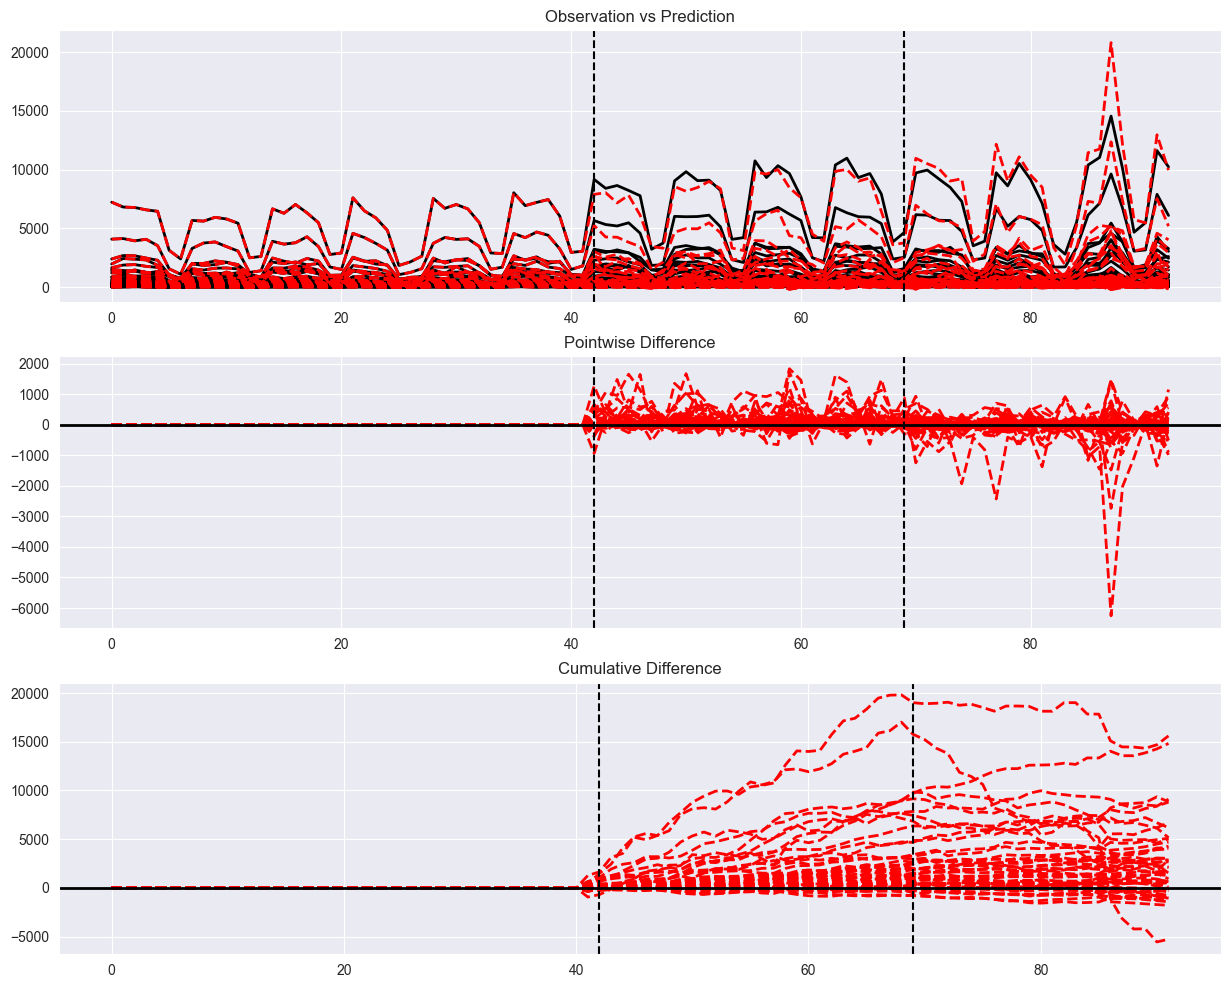

In [62]:
tbr.plot(legend=False)

In [63]:
tbr.summary()

,Average,Cumulative
Actual,720.913237,973232.87
Predicted,621.288067,838738.891088
,,
Absolute Effect,99.62517,134493.978912
,,
Relative Effect,16.035262,16.035262


In [84]:
#control_units = pd.DataFrame(wide_df.loc[[unit for unit in pds.units if unit not in treated_units]] ).T
#treated_units = pd.DataFrame(wide_df.loc[treated_units].sum(axis=0), columns=['treated'])
#wide_agg = pd.concat([treated_units, control_units], axis=1)
#wide_agg.columns = treated_units.index


In [78]:
wide_agg.T

date,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-10,2015-01-11,2015-01-12,2015-01-13,2015-01-14,...,2015-03-29,2015-03-30,2015-03-31,2015-04-01,2015-04-02,2015-04-03,2015-04-04,2015-04-05,2015-04-06,2015-04-07
treated,30141.78,31671.03,31503.97,29425.68,26968.16,13670.65,10037.50,26511.06,25596.64,26967.59,...,12594.88,25571.82,46703.97,49919.65,73486.19,50904.01,23250.05,25451.46,55272.21,45519.44
2,5342.56,5952.46,6040.20,5539.52,5865.20,2413.62,2114.20,5807.51,4818.08,5342.42,...,2022.26,4978.16,9096.13,9292.64,12965.73,9827.24,4289.66,4805.18,10773.93,8906.44
3,4958.89,5263.24,5231.30,4634.11,4358.55,2443.12,1788.17,4219.14,4344.26,4415.26,...,2191.91,4120.10,8002.69,8455.96,12057.30,8556.54,4248.07,3796.85,8924.78,7260.99
5,2776.79,3084.68,2877.21,2667.54,2533.92,1420.65,1017.58,2705.21,2668.40,2410.60,...,1038.27,2247.32,4695.00,5013.22,7639.04,5255.47,2300.76,2239.18,4570.55,4110.12
8,1793.64,2149.63,2111.89,1771.87,1624.06,1081.46,706.37,1960.65,1611.01,1889.39,...,841.47,1511.83,2801.96,3387.87,5595.08,3722.33,1815.66,1773.26,3356.38,3129.86
10,1827.21,1484.51,1922.99,1582.03,1506.66,707.87,419.88,1588.38,1386.57,1433.33,...,502.17,1300.72,2631.12,2894.09,5760.25,3204.39,1469.16,1237.81,3258.69,2282.62
11,1501.10,1523.06,1414.38,1431.12,1325.66,629.22,587.82,1360.05,1281.83,1513.52,...,583.60,1287.10,2214.24,2393.46,3585.53,2251.35,1365.21,1307.35,2937.72,2135.59
13,1366.81,1465.22,1162.51,1426.26,1076.18,565.31,568.07,1141.65,1396.54,1212.82,...,508.96,919.36,2200.57,2139.71,3881.46,2644.99,1469.16,931.83,2749.31,2275.63
16,1016.72,1118.19,1114.07,1270.49,880.51,565.31,409.99,948.06,1157.14,957.22,...,637.90,1055.56,1927.20,1892.82,3110.68,1906.06,866.25,1126.53,2212.01,1673.45
17,963.96,1190.49,1152.82,846.99,860.95,344.10,306.26,1146.61,1087.31,917.13,...,359.66,844.45,1544.50,1947.69,2546.35,1878.44,790.01,792.74,1932.89,1785.49


In [79]:
pds = PanelDataset(wide_agg.T
                , treated_periods=[TimePeriod(start=test_start, end=test_end) ]
                , treated_units=['treated'])

In [80]:
pds


        Panel Dataset Summary
        ---------------------
        Number of time points: 93
        Number of units: 51
        Number of treated units: 1
        Treated units: ['treated']
        Treated periods: [TimePeriod(start='2015-02-16', end='2015-03-15')]
        

In [81]:
est = TBRRidge()
est.run_analysis(pds)

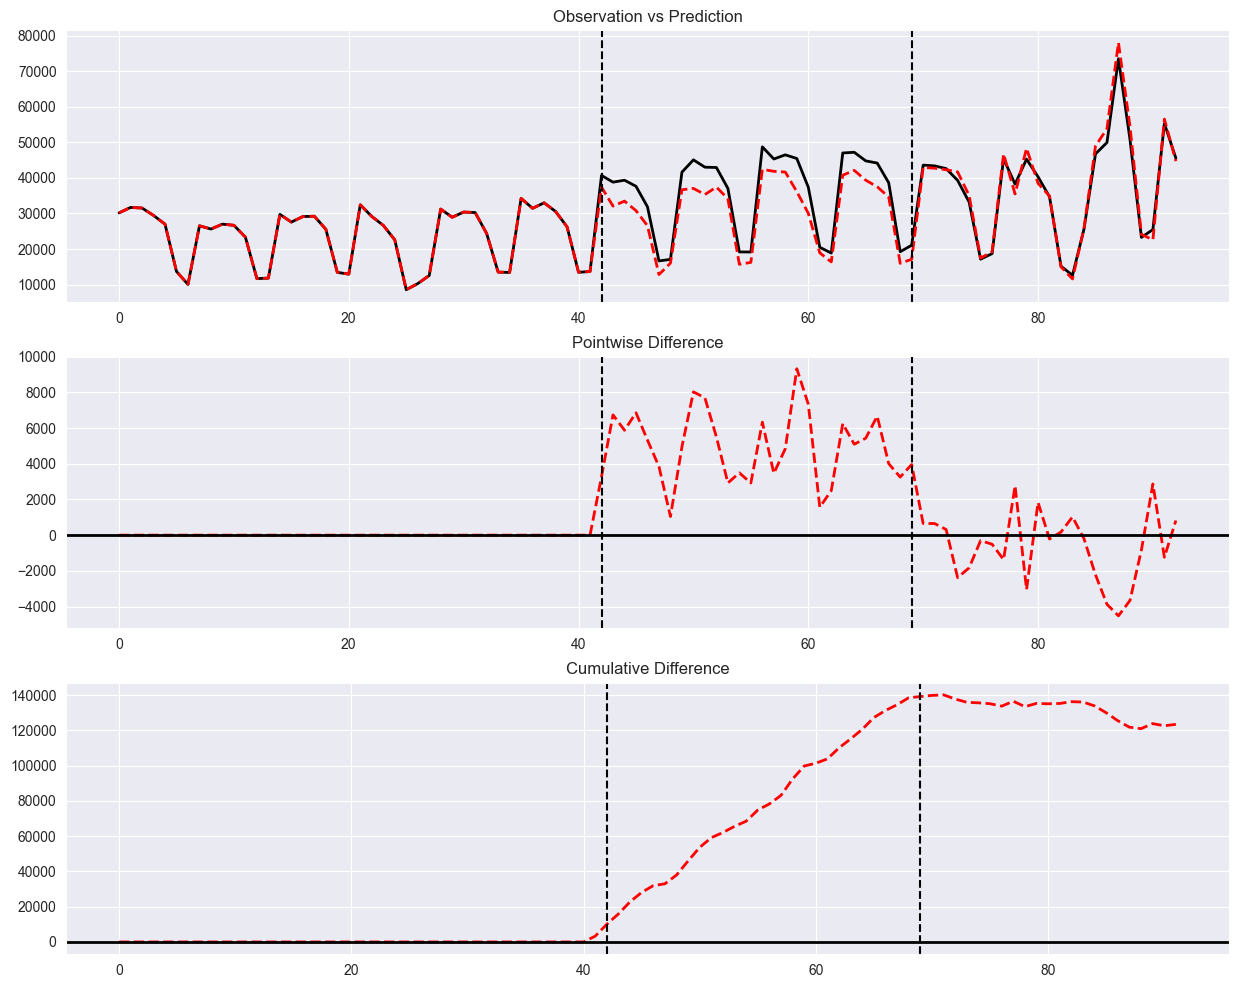

In [82]:
est.plot(legend=False)

In [83]:
est.summary()

,Average,Cumulative
Actual,36045.661852,973232.87
Predicted,31064.403374,838738.891088
,,
Absolute Effect,4981.258478,134493.978912
,,
Relative Effect,16.035262,16.035262
